In [5]:
import torch.utils.data as data
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import torchvision.transforms as transforms
import torch.optim as optim
import importlib

import config as cfg
importlib.reload(cfg)

import dataset.dataloader as dl
importlib.reload(dl)

import classifier.cnn as classifier
importlib.reload(classifier)

<module 'classifier.cnn' from 'c:\\Users\\Asus\\Desktop\\Git\\master-projects\\advanced-machine-learning-2\\src\\classifier\\cnn.py'>

### First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [6]:
# load the data
df = pd.read_csv(cfg.LABELS_PATH)

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = dl.ButterflyDataset(df=df, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=True)

In [7]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


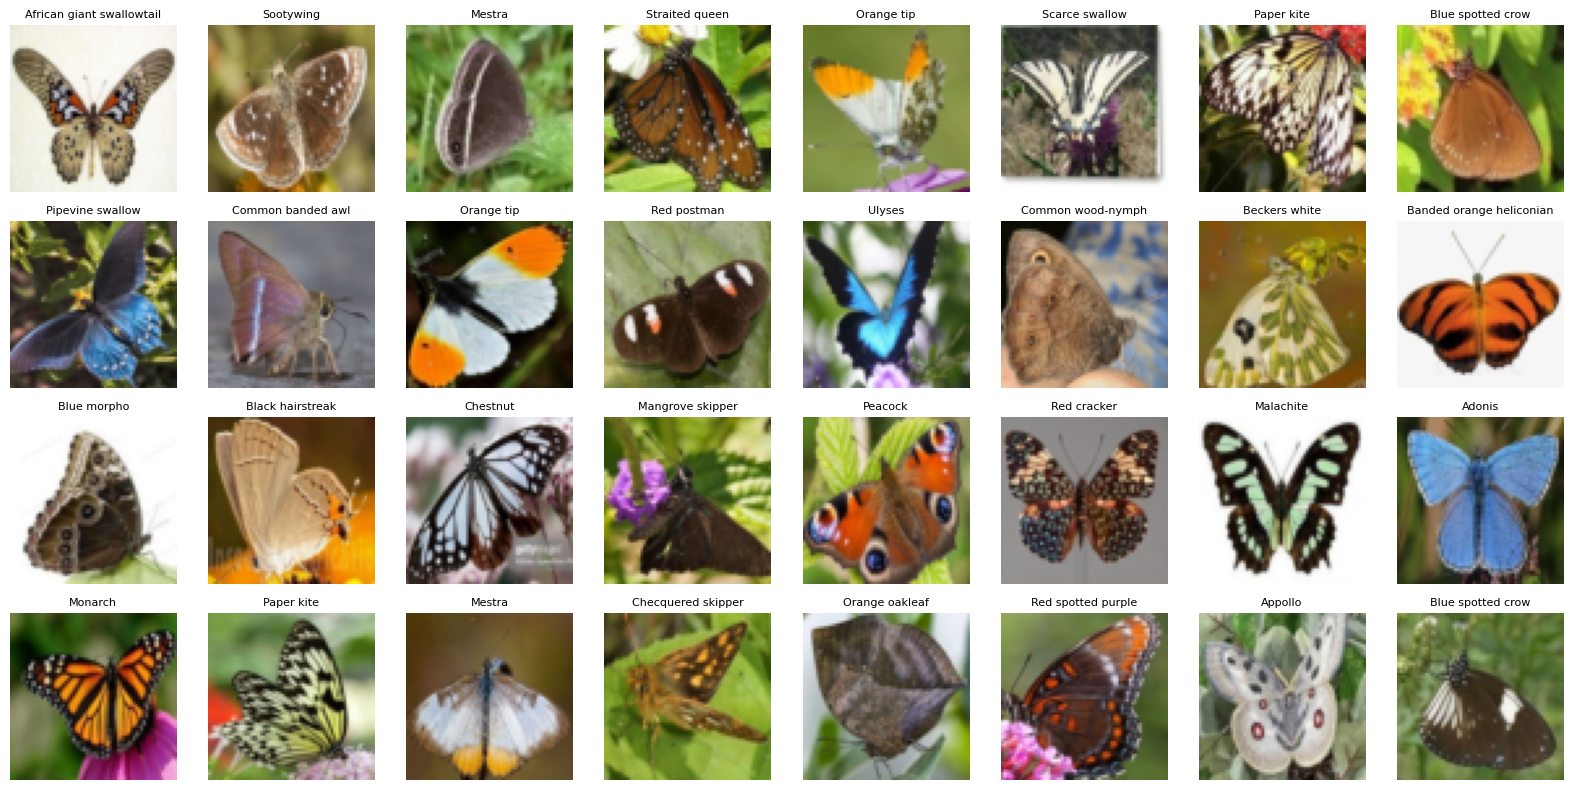

In [8]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, img in enumerate(images):
    img = img.permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Classifier

In [9]:
n_classes = len(dataset.classes)
model = classifier.BaselineCNN(num_classes=n_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()